In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer

import random
from dataclasses import dataclass

from typing import List, Dict
import re

In [2]:
@dataclass(slots=True)
class Config:
    seed: int = 42
    epochs: int = 10
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg = Config()

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(cfg.seed)
cfg

Config(seed=42, epochs=10, device=device(type='cpu'))

In [3]:
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Векторы",
        "text": (
            "Векторы это математические объекты, которые используются для представления данных в пространстве. "
            "Они имеют длину и направление, и могут быть описаны через координаты. "
            "Векторы широко применяются в физике, компьютерной графике и машинном обучении."
        )
    },
    {
        "doc_id": "doc_02",
        "title": "Матрицы",
        "text": (
            "Матрицы это прямоугольные таблицы чисел, которые используются для хранения и обработки данных. "
            "Они применяются для решения систем линейных уравнений и линейных преобразований. "
            "Матрицы являются фундаментом линейной алгебры и многих алгоритмов ML."
        )
    },
    {
        "doc_id": "doc_03",
        "title": "Скалярное произведение",
        "text": (
            "Скалярное произведение двух векторов это операция, возвращающая одно число. "
            "Она используется для вычисления угла между векторами и оценки их сходства. "
            "В машинном обучении оно часто применяется для сравнения эмбеддингов."
        )
    },
    {
        "doc_id": "doc_04",
        "title": "Нормализация векторов",
        "text": (
            "Нормализация вектора это процесс приведения его длины к единице. "
            "Для этого каждый элемент делится на евклидову норму вектора. "
            "Нормализованные векторы часто используются в поисковых системах и NLP."
        )
    },
    {
        "doc_id": "doc_05",
        "title": "Эмбеддинги",
        "text": (
            "Эмбеддинги это плотные векторные представления объектов в многомерном пространстве. "
            "Они позволяют отображать семантически похожие объекты близко друг к другу. "
            "Эмбеддинги широко используются в поиске, рекомендациях и обработке текста."
        )
    },
    {
        "doc_id": "doc_06",
        "title": "Линейная независимость",
        "text": (
            "Векторы называются линейно независимыми, если ни один из них не выражается через другие. "
            "Это важное свойство для построения базиса векторного пространства. "
            "Линейная независимость используется в анализе данных и ML."
        )
    },
    {
        "doc_id": "doc_07",
        "title": "Базис",
        "text": (
            "Базис это набор линейно независимых векторов, через которые можно выразить любой вектор. "
            "Количество векторов в базисе определяет размерность пространства. "
            "Базисы используются в линейной алгебре и PCA."
        )
    },
    {
        "doc_id": "doc_08",
        "title": "Размерность пространства",
        "text": (
            "Размерность пространства это число векторов в базисе. "
            "Она показывает, сколько независимых направлений существует в пространстве. "
            "В машинном обучении размерность связана с количеством признаков."
        )
    },
    {
        "doc_id": "doc_09",
        "title": "Евклидова норма",
        "text": (
            "Евклидова норма это длина вектора в пространстве. "
            "Она вычисляется как квадратный корень суммы квадратов координат. "
            "Используется для измерения расстояний между точками."
        )
    },
    {
        "doc_id": "doc_10",
        "title": "Косинусная близость",
        "text": (
            "Косинусная близость измеряет угол между двумя векторами. "
            "Она показывает, насколько направления векторов похожи. "
            "Часто используется в поиске текстов и рекомендательных системах."
        )
    },
    {
        "doc_id": "doc_11",
        "title": "FAISS",
        "text": (
            "FAISS это библиотека для быстрого поиска ближайших векторов. "
            "Она оптимизирована для работы с большими наборами данных. "
            "FAISS используется в системах поиска и retrieval задачах."
        )
    },
    {
        "doc_id": "doc_12",
        "title": "Поиск ближайших соседей",
        "text": (
            "Поиск ближайших соседей это метод нахождения наиболее похожих объектов. "
            "Он основан на вычислении расстояний в векторном пространстве. "
            "Используется в классификации, рекомендациях и поиске."
        )
    },
    {
        "doc_id": "doc_13",
        "title": "Машинное обучение",
        "text": (
            "Машинное обучение это область искусственного интеллекта, где модели обучаются на данных. "
            "Они находят закономерности и делают прогнозы. "
            "Используется в анализе данных, NLP и компьютерном зрении."
        )
    },
    {
        "doc_id": "doc_14",
        "title": "NLP",
        "text": (
            "Обработка естественного языка занимается анализом текста и речи. "
            "Она включает задачи классификации, перевода и генерации текста. "
            "NLP используется в чат-ботах и поисковых системах."
        )
    },
    {
        "doc_id": "doc_15",
        "title": "Рекомендательные системы",
        "text": (
            "Рекомендательные системы предлагают пользователю релевантный контент. "
            "Они используют поведение пользователя и историю взаимодействий. "
            "Применяются в Netflix, YouTube и интернет-магазинах."
        )
    },
    {
        "doc_id": "doc_16",
        "title": "Сходство текстов",
        "text": (
            "Сходство текстов определяется через сравнение их векторных представлений. "
            "Чем ближе векторы, тем более похожи тексты. "
            "Используется в поиске и дедупликации данных."
        )
    },
    {
        "doc_id": "doc_17",
        "title": "Линейные преобразования",
        "text": (
            "Линейные преобразования сохраняют операции сложения и умножения на число. "
            "Они изменяют пространство, но сохраняют его структуру. "
            "Используются в графике и машинном обучении."
        )
    },
    {
        "doc_id": "doc_18",
        "title": "Собственные значения",
        "text": (
            "Собственные значения матрицы описывают масштабирование при преобразованиях. "
            "Они помогают анализировать структуру данных. "
            "Используются в PCA и спектральном анализе."
        )
    },
    {
        "doc_id": "doc_19",
        "title": "Собственные векторы",
        "text": (
            "Собственные векторы матрицы не меняют направление при преобразовании. "
            "Они только масштабируются собственным значением. "
            "Применяются в анализе данных и ML."
        )
    },
    {
        "doc_id": "doc_20",
        "title": "Проекция вектора",
        "text": (
            "Проекция вектора это отображение одного вектора на другой. "
            "Она вычисляется через скалярное произведение. "
            "Используется в геометрии и машинном обучении."
        )
    },
    {
        "doc_id": "doc_21",
        "title": "Метрика расстояния",
        "text": (
            "Метрики расстояния используются для измерения различий между объектами. "
            "Они определяют, насколько точки близки друг к другу. "
            "Применяются в кластеризации и поиске."
        )
    },
    {
        "doc_id": "doc_22",
        "title": "Кластеризация",
        "text": (
            "Кластеризация это метод машинного обучения для группировки объектов. "
            "Она объединяет похожие данные в кластеры. "
            "Используется в анализе данных и сегментации пользователей."
        )
    },
    {
        "doc_id": "doc_23",
        "title": "RAG",
        "text": (
            "RAG это подход Retrieval Augmented Generation. "
            "Он объединяет поиск информации и генерацию текста. "
            "Используется в современных AI системах и чат-ботах."
        )
    },
    {
        "doc_id": "doc_24",
        "title": "Индексирование",
        "text": (
            "Индексирование ускоряет поиск данных за счет специальной структуры хранения. "
            "Оно позволяет быстро находить нужную информацию. "
            "Используется в базах данных и поисковых системах."
        )
    },
    {
        "doc_id": "doc_25",
        "title": "Векторные пространства",
        "text": (
            "Векторное пространство это множество объектов с операциями сложения и умножения. "
            "Оно является основой линейной алгебры. "
            "Используется в математике и машинном обучении."
        )
    }
]

In [4]:
def get_chunks(text: str, chunk_size: int, overlap: int) -> List[str]:
    if overlap >= chunk_size:
        raise ValueError("Overlap cannot be greater than or equal to chunk size")
    if overlap < 0:
        raise ValueError("Overlap cannot be negative")
    words = text.split()
    chunks = []

    step = chunk_size - overlap

    for start in range(0, len(words), step):
        end = start + chunk_size

        chunk_words = words[start:end]

        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))

        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, text: List[str]) -> np.ndarray:
        raise NotImplementedError
    
    def encode_queries(self, text: List[str]) -> np.ndarray:
        raise NotImplementedError
    
    
class SentenseTransformerBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: torch.device):
        from sentence_transformers import SentenceTransformer
        self.name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f'SentenseTransformer-{model_name}'
        
    def fit_documents(self, text: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            text,
            show_progress_bar=True,
            normalize_embeddings=True,
            convert_to_numpy=True
        )
        return vectors.astype(np.float32)
    
    def encode_queries(self, text: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            text,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True
        )
        return vectors.astype(np.float32)
    

@dataclass
class RetrieverArtifacts:
    backend_name: str
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    backend: EmbeddingBackend
    index: object

def build_retriever(
    documents: List[Dict[str, str]],
    chunk_size: int = 28,
    overlap: int = 8,
    device: str = cfg.device
) -> RetrieverArtifacts:
    rows = []
    for doc in documents:
        chunks = get_chunks(doc["text"], chunk_size, overlap)
        for chunk_id, chunk_text_value in enumerate(chunks, start=1):
            rows.append({
                "doc_id": doc["doc_id"],
                "title": doc['title'],
                'chunk_id': f'{doc["doc_id"]}_chunk_{chunk_id:02d}',
                'chunk_text': chunk_text_value
            }
        )
    
    chunks_df = pd.DataFrame(rows)
    backend = SentenseTransformerBackend("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", device=device)
    chunks_vectors = backend.fit_documents(chunks_df['chunk_text'].tolist())
    
    try:
        import faiss
        index = faiss.IndexFlatIP(chunks_vectors.shape[1])
        index.add(chunks_vectors)
        
    except ImportError:
        index = chunks_vectors
        
    
    return RetrieverArtifacts(
        backend_name=backend.backend_name,
        chunks_df=chunks_df,
        chunk_vectors=chunks_vectors,
        backend=backend,
        index=index
    )
    
def search_chunks(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype(np.float32)
    
    try:
        import faiss
        scores, indices = artifacts.index.search(query_vector, top_k)
        scores = scores[0]
        indices = indices[0]
    except ImportError:
        similarities = (artifacts.chunk_vectors @ query_vector.T).reshape(-1)
        indices = np.argsort(-similarities)[:top_k]
        scores = similarities[indices]
        
    result = artifacts.chunks_df.iloc[indices].copy().reset_index(drop=True)
    result.insert(0, 'rank', np.arange(1, len(result) + 1))
    result['score'] = scores
    return result[['rank', 'score', 'doc_id', 'title', 'chunk_id', 'chunk_text']]

In [5]:
artifacts = build_retriever(
    documents,
    chunk_size=24,
    overlap=6,
    device=cfg.device
)

print("Using backend:", artifacts.backend_name)
print("Quantity chunks:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

/Users/mazxal/PycharmProjects/AI-Mirea-Course/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10632.02it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 2/2 [00:00<00:00,  8.53it/s]

Using backend: SentenseTransformer-sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Quantity chunks: 33


,doc_id,title,chunk_id,chunk_text
0,doc_01,Векторы,doc_01_chunk_01,"Векторы это математические объекты, которые ис..."
1,doc_01,Векторы,doc_01_chunk_02,быть описаны через координаты. Векторы широко ...
2,doc_02,Матрицы,doc_02_chunk_01,"Матрицы это прямоугольные таблицы чисел, котор..."
3,doc_02,Матрицы,doc_02_chunk_02,уравнений и линейных преобразований. Матрицы я...
4,doc_03,Скалярное произведение,doc_03_chunk_01,Скалярное произведение двух векторов это опера...


## Предметная область: ML и математика

По этой области разумно делать, потому что темы довольно хорошо связанны и имеют в некотрых частях небольщие пересечения -> идеально для учебного варианта

In [6]:
sample_queries = [
    "Зачем нужны векторы?",
    'Где используются матрицы',
    'Для чего нужны сообственные значения векторов'
]

for query in sample_queries:
    print(f"Query: {query}")
    search_result = search_chunks(query, artifacts, top_k=3)
    display(search_result)

Query: Зачем нужны векторы?


,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.746653,doc_04,Нормализация векторов,doc_04_chunk_01,Нормализация вектора это процесс приведения ег...
1,2,0.664812,doc_20,Проекция вектора,doc_20_chunk_01,Проекция вектора это отображение одного вектор...
2,3,0.660599,doc_07,Базис,doc_07_chunk_01,"Базис это набор линейно независимых векторов, ..."


Query: Где используются матрицы


,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.598014,doc_07,Базис,doc_07_chunk_02,пространства. Базисы используются в линейной а...
1,2,0.579777,doc_18,Собственные значения,doc_18_chunk_01,Собственные значения матрицы описывают масштаб...
2,3,0.562791,doc_07,Базис,doc_07_chunk_01,"Базис это набор линейно независимых векторов, ..."


Query: Для чего нужны сообственные значения векторов


,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.795577,doc_04,Нормализация векторов,doc_04_chunk_01,Нормализация вектора это процесс приведения ег...
1,2,0.734897,doc_07,Базис,doc_07_chunk_01,"Базис это набор линейно независимых векторов, ..."
2,3,0.726297,doc_20,Проекция вектора,doc_20_chunk_01,Проекция вектора это отображение одного вектор...


In [7]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []
    
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)
    
    query_vec = matrix[0]
    sentence_vecs = matrix[1:]
    
    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)
    
    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]

def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc['title'] + '. ' + doc['text'] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)
    
    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]
    
    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)
    
    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc['text'], top_n=2)
    
    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось найти релевантные предложения в документе. "
            "Система выбрала наиболее похожий документ целиком."
        )
        
    return {
        'answer': answer,
        'source_doc_id': best_doc['doc_id'],
        'source_title': best_doc['title'],
        'score': float(scores[best_idx])
    }
    

In [8]:
baeline_example = answer_without_retrieval("Зачем нужны векторы?", documents)
display(pd.DataFrame([baeline_example]))

,answer,source_doc_id,source_title,score
0,"Векторы широко применяются в физике, компьютер...",doc_01,Векторы,0.088924


In [9]:
def build_context_from_retrieval(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 3
) -> tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts, top_k)
    context_blocks = []
    
    for _, row in retrieved.iterrows():
        block = (
            f'[Source: {row["doc_id"]} | {row["title"]} | score={row["score"]:.4f}]\n'
            f'{row["chunk_text"]}'
        )
        context_blocks.append(block)
    
    context = "\n\n".join(context_blocks)
    return context, retrieved

In [10]:
query = 'Для чего нужны сообственные значения векторов'
context, retrieved_df = build_context_from_retrieval(query, artifacts, top_k=3)

display(Markdown(f"### Context for query: '{query}'"))
display(retrieved_df)
print(context)

### Context for query: 'Для чего нужны сообственные значения векторов'

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.795577,doc_04,Нормализация векторов,doc_04_chunk_01,Нормализация вектора это процесс приведения ег...
1,2,0.734897,doc_07,Базис,doc_07_chunk_01,"Базис это набор линейно независимых векторов, ..."
2,3,0.726297,doc_20,Проекция вектора,doc_20_chunk_01,Проекция вектора это отображение одного вектор...


[Source: doc_04 | Нормализация векторов | score=0.7956]
Нормализация вектора это процесс приведения его длины к единице. Для этого каждый элемент делится на евклидову норму вектора. Нормализованные векторы часто используются в поисковых

[Source: doc_07 | Базис | score=0.7349]
Базис это набор линейно независимых векторов, через которые можно выразить любой вектор. Количество векторов в базисе определяет размерность пространства. Базисы используются в линейной алгебре

[Source: doc_20 | Проекция вектора | score=0.7263]
Проекция вектора это отображение одного вектора на другой. Она вычисляется через скалярное произведение. Используется в геометрии и машинном обучении.


In [11]:
def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Source:")]
    
    sentences_pool = []
    for line in content_lines:
        sentences_pool.extend(split_into_sentences(line))
        
    sentence_pool = [s for s in sentences_pool if len(s.split()) >= 4]
    
    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."
    
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)
    
    query_vec = matrix[0]
    sentence_vecs = matrix[1:]
    
    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norm = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    
    scores = (sentence_vecs @ query_vec) / (sent_norm * query_norm)
    
    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()
    
    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0 or normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break
    
    if not selected_sentences:
        return "В найденном контексте недостаточно релевантной информации для ответа."
    
    return " ".join(selected_sentences)

In [12]:
answer_example = generate_answer_from_context(query, context)
print(answer_example)

Для этого каждый элемент делится на евклидову норму вектора. Количество векторов в базисе определяет размерность пространства.


In [13]:
def mini_rag_answer(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
    max_sentences: int = 2
) -> Dict[str, object]:
    context, retrieved_df = build_context_from_retrieval(query, artifacts, top_k)
    answer = generate_answer_from_context(query, context, max_sentences)
    
    return {
        'query': query,
        'answer': answer,
        'context': context,
        'sources': retrieved_df
    }


In [14]:
rag_result = mini_rag_answer(
    "Почему векторы важны в машинном обучении?",
    artifacts,
    top_k=3,
)

display(Markdown(f"**Query:** '{rag_result['query']}'"))
display(Markdown(f"**Answer:** {rag_result['answer']}"))
display(Markdown("**Sources:**"))
display(rag_result['sources'])

**Query:** 'Почему векторы важны в машинном обучении?'

**Answer:** Используется в геометрии и машинном обучении. Векторы широко применяются в физике, компьютерной графике и машинном обучении.

**Sources:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.743452,doc_20,Проекция вектора,doc_20_chunk_01,Проекция вектора это отображение одного вектор...
1,2,0.727361,doc_01,Векторы,doc_01_chunk_02,быть описаны через координаты. Векторы широко ...
2,3,0.686379,doc_04,Нормализация векторов,doc_04_chunk_01,Нормализация вектора это процесс приведения ег...


In [15]:
comparion_queries = [
    "Почему векторы важны в машинном обучении?",
    "Какие есть методы векторизации?",
    "Для чего нужен FAISS?",
    "Матрицы это векторы?",
    "Чем помогают векторы в NLP?"
]

comparison_rows = []

for query in comparion_queries:
    baseline = answer_without_retrieval(query, documents)
    rag = mini_rag_answer(query, artifacts, top_k=3)
    
    comparison_rows.append({
        'query': query,
        'baseline_doc_id': baseline['source_doc_id'],
        'baseline_score': baseline['score'],
        'baseline_answer': baseline['answer'],
        'rag_answer': rag['answer'],
    })
    
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,query,baseline_doc_id,baseline_score,baseline_answer,rag_answer
0,Почему векторы важны в машинном обучении?,doc_01,0.138211,"Векторы широко применяются в физике, компьютер...",Используется в геометрии и машинном обучении. ...
1,Какие есть методы векторизации?,doc_01,0.000000,Не удалось найти релевантные предложения в док...,В найденном контексте недостаточно релевантной...
2,Для чего нужен FAISS?,doc_11,0.179428,FAISS это библиотека для быстрого поиска ближа...,FAISS это библиотека для быстрого поиска ближа...
3,Матрицы это векторы?,doc_02,0.207400,"Матрицы это прямоугольные таблицы чисел, котор...",Нормализованные векторы часто используются в п...
4,Чем помогают векторы в NLP?,doc_01,0.079358,"Векторы широко применяются в физике, компьютер...",Нормализованные векторы часто используются в п...


In [16]:
for _, row in comparison_df.iterrows():
    print(f"Query: {row['query']}")
    print(f"Baseline Answer (doc_id={row['baseline_doc_id']}, score={row['baseline_score']:.4f}): {row['baseline_answer']}")
    print(f"RAG Answer: {row['rag_answer']}")
    print("-" * 80)

Query: Почему векторы важны в машинном обучении?
Baseline Answer (doc_id=doc_01, score=0.1382): Векторы широко применяются в физике, компьютерной графике и машинном обучении. Векторы это математические объекты, которые используются для представления данных в пространстве.
RAG Answer: Используется в геометрии и машинном обучении. Векторы широко применяются в физике, компьютерной графике и машинном обучении.
--------------------------------------------------------------------------------
Query: Какие есть методы векторизации?
Baseline Answer (doc_id=doc_01, score=0.0000): Не удалось найти релевантные предложения в документе. Система выбрала наиболее похожий документ целиком.
RAG Answer: В найденном контексте недостаточно релевантной информации для ответа.
--------------------------------------------------------------------------------
Query: Для чего нужен FAISS?
Baseline Answer (doc_id=doc_11, score=0.1794): FAISS это библиотека для быстрого поиска ближайших векторов. FAISS используется

In [17]:
qa_benchmark = [
    {
        "query_id": "q01",
        "query": "Для чего нужны сообственные значения векторов?",
        "relevant_doc_ids": ["doc_18", "doc_19"],
        "expected_keywords": ['PCA', 'спектральный анализ', 'масштабирование', 'структура данных']
    },
    {
        "query_id": "q02",
        "query": "Как работает FAISS?",
        "relevant_doc_ids": ["doc_11"],
        "expected_keywords": ['поиск ближайших векторов', 'оптимизация', 'большие наборы данных']
    },
    {
        "query_id": "q03",
        "query": "Зачем нужна нормализация векторов?",
        "relevant_doc_ids": ["doc_04"],
        "expected_keywords": ['единичная длина', 'евклидова норма', 'поиск', 'NLP']
    },
    {
        "query_id": "q04",
        "query": "Как векторы помогают в NLP?",
        "relevant_doc_ids": ["doc_05", "doc_10"],
        "expected_keywords": ['эмбеддинги', 'семантическая близость', 'косинусная близость', 'поиск текстов']
    }
]

def keyword_recall(answer: str, expected_keywords: List[str]) -> float:
    answer_lower = answer.lower()
    found_keywords = [kw for kw in expected_keywords if kw.lower() in answer_lower]
    return len(found_keywords) / len(expected_keywords) if expected_keywords else np.nan

def evaluate_mini_rag(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrieverArtifacts,
    top_k: int = 3
) -> pd.DataFrame:
    rows = []
    
    for item in benchmark_rows:
        query = item['query']
        
        relevant_doc_ids = item['relevant_doc_ids']
        expected_keywords = item['expected_keywords']
        
        retrieved = search_chunks(query, artifacts, top_k)
        predicted_doc_ids = retrieved['doc_id'].tolist()
        retrieval_hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
        
        baseline = answer_without_retrieval(query, documents)
        rag = mini_rag_answer(query, artifacts, top_k)
        
        rows.append(
            {
                "query_id": item['query_id'],
                "query": query,
                "relevant_doc_ids": relevant_doc_ids,
                "predicted_doc_ids": predicted_doc_ids,
                f"retrieval_hit@{top_k}": retrieval_hit,
                "baseline_keyword_recall": keyword_recall(baseline['answer'], expected_keywords),
                "rag_keyword_recall": keyword_recall(rag['answer'], expected_keywords),
                "baseline_answer": baseline['answer'],
                "rag_answer": rag['answer']
            }
        )
        
    return pd.DataFrame(rows)

In [18]:
evaluation_df = evaluate_mini_rag(qa_benchmark, artifacts, top_k=3)
display(evaluation_df)

,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,baseline_keyword_recall,rag_keyword_recall,baseline_answer,rag_answer
0,q01,Для чего нужны сообственные значения векторов?,"[doc_18, doc_19]","[doc_04, doc_07, doc_20]",0,0.25,0.0,Собственные значения матрицы описывают масштаб...,Для этого каждый элемент делится на евклидову ...
1,q02,Как работает FAISS?,[doc_11],"[doc_11, doc_02, doc_13]",1,0.00,0.0,FAISS используется в системах поиска и retriev...,FAISS используется в системах поиска и retriev...
2,q03,Зачем нужна нормализация векторов?,[doc_04],"[doc_04, doc_06, doc_07]",1,0.00,0.0,Нормализация вектора это процесс приведения ег...,Нормализация вектора это процесс приведения ег...
3,q04,Как векторы помогают в NLP?,"[doc_05, doc_10]","[doc_04, doc_04, doc_20]",0,0.00,0.0,"Векторы широко применяются в физике, компьютер...",Нормализованные векторы часто используются в п...


In [19]:
summary_df = pd.DataFrame({
    "metrics": ["retrieval_hit@3", "mean_baseline_keyword_recall", "mean_rag_keyword_recall"],
    "value": [
        evaluation_df[f"retrieval_hit@3"].mean(),
        evaluation_df["baseline_keyword_recall"].mean(),
        evaluation_df["rag_keyword_recall"].mean()
    ]
})
display(summary_df)

,metrics,value
0,retrieval_hit@3,0.5000
1,mean_baseline_keyword_recall,0.0625
2,mean_rag_keyword_recall,0.0000


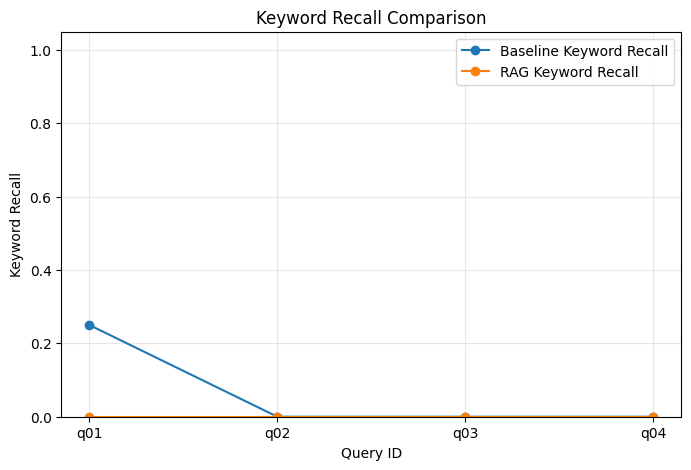

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(
    evaluation_df['query_id'],
    evaluation_df['baseline_keyword_recall'],
    marker='o',
    label='Baseline Keyword Recall'
)

plt.plot(
    evaluation_df['query_id'],
    evaluation_df['rag_keyword_recall'],
    marker='o',
    label='RAG Keyword Recall'
)

plt.title('Keyword Recall Comparison')
plt.xlabel('Query ID')
plt.ylabel('Keyword Recall')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [21]:
pd.set_option('display.max_colwidth', None)

artifacts = build_retriever(
    documents,
    chunk_size=24,
    overlap=6,
    device=cfg.device
)

rag_result = mini_rag_answer(
    "Почему векторы важны в машинном обучении?",
    artifacts,
    top_k=3,
)

display(pd.DataFrame([rag_result]))

artifacts = build_retriever(
    documents,
    chunk_size=10,
    overlap=6,
    device=cfg.device
)

rag_result = mini_rag_answer(
    "Почему векторы важны в машинном обучении?",
    artifacts,
    top_k=3,
)

display(pd.DataFrame([rag_result]))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18110.67it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 2/2 [00:00<00:00, 13.98it/s]


,query,answer,context,sources
0,Почему векторы важны в машинном обучении?,"Используется в геометрии и машинном обучении. Векторы широко применяются в физике, компьютерной графике и машинном обучении.","[Source: doc_20 | Проекция вектора | score=0.7435]\nПроекция вектора это отображение одного вектора на другой. Она вычисляется через скалярное произведение. Используется в геометрии и машинном обучении.\n\n[Source: doc_01 | Векторы | score=0.7274]\nбыть описаны через координаты. Векторы широко применяются в физике, компьютерной графике и машинном обучении.\n\n[Source: doc_04 | Нормализация векторов | score=0.6864]\nНормализация вектора это процесс приведения его длины к единице. Для этого каждый элемент делится на евклидову норму вектора. Нормализованные векторы часто используются в поисковых","rank score doc_id title chunk_id \ 0 1 0.743452 doc_20 Проекция вектора doc_20_chunk_01 1 2 0.727361 doc_01 Векторы doc_01_chunk_02 2 3 0.686379 doc_04 Нормализация векторов doc_04_chunk_01 chunk_text 0 Проекция вектора это отображение одного вектора на другой. Она вычисляется через скалярное произведение. Используется в геометрии и машинном обучении. 1 быть описаны через координаты. Векторы широко применяются в физике, компьютерной графике и машинном обучении. 2 Нормализация вектора это процесс приведения его длины к единице. Для этого каждый элемент делится на евклидову норму вектора. Нормализованные векторы часто используются в поисковых"


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 22979.01it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 4/4 [00:00<00:00, 24.32it/s]


,query,answer,context,sources
0,Почему векторы важны в машинном обучении?,Нормализованные векторы часто используются Нормализованные векторы часто используются в поисковых системах и,"[Source: doc_16 | Сходство текстов | score=0.6776]\nсравнение их векторных представлений. Чем ближе векторы, тем более похожи\n\n[Source: doc_04 | Нормализация векторов | score=0.6722]\nэлемент делится на евклидову норму вектора. Нормализованные векторы часто используются\n\n[Source: doc_04 | Нормализация векторов | score=0.6681]\nнорму вектора. Нормализованные векторы часто используются в поисковых системах и","rank score doc_id title chunk_id \ 0 1 0.677616 doc_16 Сходство текстов doc_16_chunk_02 1 2 0.672161 doc_04 Нормализация векторов doc_04_chunk_04 2 3 0.668121 doc_04 Нормализация векторов doc_04_chunk_05 chunk_text 0 сравнение их векторных представлений. Чем ближе векторы, тем более похожи 1 элемент делится на евклидову норму вектора. Нормализованные векторы часто используются 2 норму вектора. Нормализованные векторы часто используются в поисковых системах и"


## Выводы

Здесь мы видим, что с низким chunk_size мы теряем точность, могут быть повторы + теряется общая суть вопроса и ответа

In [22]:
artifacts = build_retriever(
    documents,
    chunk_size=28,
    overlap=8,
    device=cfg.device   
)

new_documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_26",
        "title": "Сортировка пузырьком",
        "text": (
            "Сортировка пузырьком — это простой алгоритм сортировки, который повторно сравнивает соседние элементы и меняет их местами, если они находятся в неправильном порядке. "
            "Он является одним из самых простых методов сортировки и часто используется для обучения основам алгоритмов. "
            "Один из самых распостраненных алгоритмов сортировки, но работающий очень долго за O(n ^ 2)"
        )
    },
    {
        "doc_id": "doc_27",
        "title": "Быстрая сортировка",
        "text": (
            "Быстрая сортировка — это эффективный алгоритм сортировки, который использует стратегию 'разделяй и властвуй'. "
            "Он выбирает опорный элемент и разделяет массив на две части: элементы меньше опорного и элементы больше опорного. "
            "Затем рекурсивно сортирует обе части. Быстрая сортировка работает за O(n log n) в среднем случае."
        )
    }
]

new_queries = [
    'За сколько работает сортировка пузырьком?',
    'Какой алгоритм сортировки быстрее?',
    'Как работает быстрая сортировка?'
]

for query in new_queries:
    print(f"Query: {query}")
    search_result = search_chunks(query, artifacts, top_k=3)
    display(search_result)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16880.36it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 1/1 [00:00<00:00,  7.57it/s]

Query: За сколько работает сортировка пузырьком?


,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.188866,doc_25,Векторные пространства,doc_25_chunk_01,Векторное пространство это множество объектов с операциями сложения и умножения. Оно является основой линейной алгебры. Используется в математике и машинном обучении.
1,2,0.173804,doc_02,Матрицы,doc_02_chunk_02,линейных преобразований. Матрицы являются фундаментом линейной алгебры и многих алгоритмов ML.
2,3,0.154852,doc_09,Евклидова норма,doc_09_chunk_01,Евклидова норма это длина вектора в пространстве. Она вычисляется как квадратный корень суммы квадратов координат. Используется для измерения расстояний между точками.


Query: Какой алгоритм сортировки быстрее?


,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.629981,doc_24,Индексирование,doc_24_chunk_01,Индексирование ускоряет поиск данных за счет специальной структуры хранения. Оно позволяет быстро находить нужную информацию. Используется в базах данных и поисковых системах.
1,2,0.481311,doc_11,FAISS,doc_11_chunk_01,FAISS это библиотека для быстрого поиска ближайших векторов. Она оптимизирована для работы с большими наборами данных. FAISS используется в системах поиска и retrieval задачах.
2,3,0.453356,doc_22,Кластеризация,doc_22_chunk_01,Кластеризация это метод машинного обучения для группировки объектов. Она объединяет похожие данные в кластеры. Используется в анализе данных и сегментации пользователей.


Query: Как работает быстрая сортировка?


,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.522098,doc_24,Индексирование,doc_24_chunk_01,Индексирование ускоряет поиск данных за счет специальной структуры хранения. Оно позволяет быстро находить нужную информацию. Используется в базах данных и поисковых системах.
1,2,0.369950,doc_11,FAISS,doc_11_chunk_01,FAISS это библиотека для быстрого поиска ближайших векторов. Она оптимизирована для работы с большими наборами данных. FAISS используется в системах поиска и retrieval задачах.
2,3,0.336779,doc_03,Скалярное произведение,doc_03_chunk_02,В машинном обучении оно часто применяется для сравнения эмбеддингов.


In [27]:
all_docs = documents + new_documents

updated_artifacts = build_retriever(
    all_docs,
    chunk_size=28,
    overlap=8,
    device=cfg.device
)

extended_queries = [
    {
        "query_id": "q05",
        "query": 'За сколько работает сортировка пузырьком?',
        "relevant_doc_ids": ['doc_26'],
        "expected_keywords": ['O(n ^ 2)', 'неэффективный', 'простые алгоритмы сортировки']
    },
    {
        "query_id": "q06",
        "query": 'Какой алгоритм сортировки быстрее?',
        "relevant_doc_ids": ['doc_27'],
        "expected_keywords": ['быстрая сортировка', 'O(n log n)', 'эффективный алгоритм сортировки']
    },
    {
        "query_id": "q07",
        "query": "Как работает быстрая сортировка?",
        "relevant_doc_ids": ["doc_26", "doc_27"],
        "expected_keywords": ['быстрая сортировка', 'якорный элемент', 'быстро']
    }
]

before_update_eval = evaluate_mini_rag(extended_queries, artifacts, top_k=3)
after_update_eval = evaluate_mini_rag(extended_queries, updated_artifacts, top_k=3)

comparison_df = before_update_eval.merge(
    after_update_eval,
    on=['query_id', 'query'],
    suffixes=('_before', '_after')
)
comparison_df = comparison_df.rename(columns={"predicted_doc_ids_before":"before_retrieved_sources", 
                              "predicted_doc_ids_after":"after_retrieved_sources",})
comparison_df['changed'] = comparison_df.apply(
    lambda row: row['before_retrieved_sources'] != row['after_retrieved_sources'], axis=1
)
display(comparison_df)
save_comparison_df = comparison_df[['query', 'before_retrieved_sources', 'after_retrieved_sources', 'changed']]
save_comparison_df.to_csv("./artifacts/retrieval_before_after_update.csv", index=False)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17268.01it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 2/2 [00:00<00:00, 16.65it/s]


,query_id,query,relevant_doc_ids_before,before_retrieved_sources,retrieval_hit@3_before,baseline_keyword_recall_before,rag_keyword_recall_before,baseline_answer_before,rag_answer_before,relevant_doc_ids_after,after_retrieved_sources,retrieval_hit@3_after,baseline_keyword_recall_after,rag_keyword_recall_after,baseline_answer_after,rag_answer_after,changed
0,q05,За сколько работает сортировка пузырьком?,[doc_26],"[doc_25, doc_02, doc_09]",0,0.0,0.0,Индексирование ускоряет поиск данных за счет специальной структуры хранения.,В найденном контексте недостаточно релевантной информации для ответа.,[doc_26],"[doc_26, doc_27, doc_26]",1,0.0,0.000000,Индексирование ускоряет поиск данных за счет специальной структуры хранения.,"Быстрая сортировка работает за O(n log n) в среднем случае. Сортировка пузырьком — это простой алгоритм сортировки, который повторно сравнивает соседние элементы и меняет их местами, если они находятся в неправильном порядке.",True
1,q06,Какой алгоритм сортировки быстрее?,[doc_27],"[doc_24, doc_11, doc_22]",0,0.0,0.0,Не удалось найти релевантные предложения в документе. Система выбрала наиболее похожий документ целиком.,В найденном контексте недостаточно релевантной информации для ответа.,[doc_27],"[doc_27, doc_26, doc_26]",1,0.0,0.666667,Не удалось найти релевантные предложения в документе. Система выбрала наиболее похожий документ целиком.,"Быстрая сортировка — это эффективный алгоритм сортировки, который использует стратегию 'разделяй и властвуй'. распостраненных алгоритмов сортировки, но работающий очень долго за O(n ^ 2)",True
2,q07,Как работает быстрая сортировка?,"[doc_26, doc_27]","[doc_24, doc_11, doc_03]",0,0.0,0.0,Она вычисляется как квадратный корень суммы квадратов координат.,В найденном контексте недостаточно релевантной информации для ответа.,"[doc_26, doc_27]","[doc_27, doc_26, doc_26]",1,0.0,0.333333,Она вычисляется как квадратный корень суммы квадратов координат.,"Быстрая сортировка — это эффективный алгоритм сортировки, который использует стратегию 'разделяй и властвуй'.",True


## Итог по обновлению базы знаний

Как мы видим до обновления наша rag система выдала совсем странные ответы, при этом после обновления стала намного коректнее подбирать ответы!


In [28]:
rag_df = evaluate_mini_rag(qa_benchmark, artifacts, top_k=3)
rag_ans_df = rag_df[['query', 'rag_answer', 'predicted_doc_ids']]
rag_ans_df = rag_ans_df.rename(columns={"query":"question", "rag_answer":"answer", "predicted_doc_ids":"retrieved_sources"})
rag_ans_df.to_csv("./artifacts/rag_examples.csv", index=False)

baseline_ans_df = rag_df[['query', 'relevant_doc_ids', 'predicted_doc_ids', 'retrieval_hit@3']]
baseline_ans_df = baseline_ans_df.rename(columns={"relevant_doc_ids":"expected_source", "predicted_doc_ids":"retrieved_sources", "retrieval_hit@3":"hit_at_k"})
baseline_ans_df.to_csv("./artifacts/retrieval_eval.csv", index=False)